In [4]:
#复制ori
import os
import shutil
from tqdm import tqdm

def match_and_copy_files(dir1, dir2, output_dir):
    """
    匹配dir1中的文件名（如x_sort.swc）与dir2中可能为x_sort或x_reconnect的文件，
    并将匹配的文件从dir2复制到output_dir，同时统计匹配上的文件总数。
    
    参数:
    - dir1: 包含基准文件的目录
    - dir2: 待匹配文件的目录
    - output_dir: 匹配文件保存的目标目录
    """
    # 确保目标目录存在
    os.makedirs(output_dir, exist_ok=True)
    
    # 获取dir1中的基准文件列表
    dir1_files = [f for f in os.listdir(dir1) if f.endswith('.swc')]
    
    # 获取dir2中的所有文件列表
    dir2_files = os.listdir(dir2)
    
    # 匹配文件总数统计
    total_matches = 0

    # 遍历dir1中的文件，寻找dir2中可能匹配的文件
    for file in tqdm(dir1_files, desc="Matching files"):
        # 提取基准文件名的前缀（如x_sort -> x）
        base_name = file.split('_sort')[0]
        # 匹配可能的文件名
        potential_matches = [f for f in dir2_files if f.startswith(base_name) and f.endswith('.swc')]
        total_matches += len(potential_matches)
        
        # print(f"File: {file}, Matches found: {len(potential_matches)}")
        
        # 复制匹配文件到目标目录
        for match in potential_matches:
            src_path = os.path.join(dir2, match)
            dest_path = os.path.join(output_dir, match)
            shutil.copy(src_path, dest_path)
    
    # 打印匹配总数
    print(f"\nTotal matched files: {total_matches}")

# 使用示例
dir1 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\80_95\80_90\final"  # 替换为dir1的路径
dir2 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\80_95\80_90\final\2_radius" # 替换为dir2的路径
output_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level3"  # 替换为目标文件夹路径

match_and_copy_files(dir1, dir2, output_dir)


Matching files: 100%|██████████| 1739/1739 [03:44<00:00,  7.74it/s]


Total matched files: 1738


In [5]:
#soma merge
import math
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
def read_swc(filename):
    nodes = {}
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) != 7:
                print(f"警告：行格式不正确，已忽略：{line}")
                continue
            n = int(parts[0])
            T = int(parts[1])
            x = float(parts[2])
            y = float(parts[3])
            z = float(parts[4])
            radius = float(parts[5])
            P = int(float(parts[6]))
            nodes[n] = {'n': n, 'T': T, 'x': x, 'y': y, 'z': z, 'radius': radius, 'P': P, 'children': []}

    for node in nodes.values():
        P = node['P']
        if P != -1 and P in nodes:
            nodes[P]['children'].append(node['n'])
        elif P != -1:
            print(f"警告：父节点{P}不存在，节点{node['n']}的父节点设为-1")
            node['P'] = -1
    return nodes

def get_radius(nodes):    
    soma_node = None
    for node in nodes.values():
        if node['P'] == -1:
            soma_node = node
            break
    if not soma_node:
        raise ValueError("未找到 soma 节点 (P = -1)！")

    soma_coords = (soma_node['x'], soma_node['y'], soma_node['z'])
    soma_id = soma_node['n']
    soma_radius = soma_node['radius']
    return soma_radius


def prune_swc_to_sphere(nodes, radius):
    """
    以 soma 节点为中心，删除球内节点并调整球外节点连接关系。
    
    参数：
        nodes (dict): 包含节点信息的字典。
        radius (float): 球的半径。

    返回值：
        dict: 更新后的节点字典。
    """
    # 找到 soma 节点 (P = -1)
    soma_node = None
    for node in nodes.values():
        if node['P'] == -1:
            soma_node = node
            break
    if not soma_node:
        raise ValueError("未找到 soma 节点 (P = -1)！")

    soma_coords = (soma_node['x'], soma_node['y'], soma_node['z'])
    soma_id = soma_node['n']

    # 筛选需要删除的节点
    to_delete = set()
    for node in nodes.values():
        if node['n'] == soma_id:  # 跳过 soma 节点
            continue
        # 计算欧几里得距离
        dist = math.sqrt(
            (node['x'] - soma_coords[0]) ** 2 +
            (node['y'] - soma_coords[1]) ** 2 +
            (node['z'] - soma_coords[2]) ** 2
        )
        if dist < radius:
            to_delete.add(node['n'])

    # 调整球外节点的父节点
    for node in nodes.values():
        if node['P'] in to_delete:  # 父节点被删除
            node['P'] = soma_id

    # 构建新的节点字典，删除球内节点
    new_nodes = {n: node for n, node in nodes.items() if n not in to_delete}

    # 更新子节点关系
    for node in new_nodes.values():
        node['children'] = [child for child in node['children'] if child in new_nodes]

    return new_nodes

def write_swc(nodes, filename):
    with open(filename, 'w') as f:
        f.write("# H01 human neuron SWC \n")
        for n in sorted(nodes.keys()):
            node = nodes[n]
            f.write(f"{node['n']} {node['T']} {node['x']} {node['y']} {node['z']} {node['radius']} {node['P']}\n")
# 示例调用
import os

def process_all_swc_files(swc_dir, outdir):
    """
    处理文件夹内所有 SWC 文件，以 soma 节点为中心进行球内节点删除处理，
    结果保存到另一个文件夹，并输出处理进度。

    参数：
        swc_dir (str): 输入 SWC 文件夹路径。
        outdir (str): 输出文件夹路径。
    """
    if not os.path.exists(outdir):
        os.makedirs(outdir)

    # 获取文件列表
    swc_files = [file for file in os.listdir(swc_dir) if file.endswith(".swc")]
    total_files = len(swc_files)
    print(total_files)
    #swc_files = [file for file in os.listdir(swc_dir) if file.endswith('.swc')]

    # 使用 tqdm 显示进度条
    with tqdm(total=len(swc_files), desc="处理 SWC 文件") as pbar:
        for file in swc_files:
            swc_path = os.path.join(swc_dir, file)
            out_path = os.path.join(outdir, file)

            try:
                # 读取 SWC 文件
                nodes = read_swc(swc_path)

                # 获取 soma 节点半径
                soma_radius = get_radius(nodes)

                # 处理节点数据
                newnodes = prune_swc_to_sphere(nodes, radius=1 * soma_radius)

                # 写入新 SWC 文件
                write_swc(newnodes, out_path)

            except Exception as e:
                print(f"处理文件 {file} 时发生错误: {e}")

            # 更新进度条
            pbar.update(1)

    print("所有文件处理完成！")

   

# 执行函数
swc_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level3"
outdir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level333"
process_all_swc_files(swc_dir, outdir)





1738


处理 SWC 文件: 100%|██████████| 1738/1738 [11:23<00:00,  2.54it/s]

所有文件处理完成！


In [8]:
# mm->um
import os
import pandas as pd
from tqdm import tqdm

def scale_swc_file(input_file, output_file, scale_factor=1000):
    """
    将SWC文件中的x, y, z和radius字段的值缩小（除以scale_factor），其余字段保存为整数。
    
    参数:
    - input_file: 原始SWC文件路径
    - output_file: 修改后的SWC文件保存路径
    - scale_factor: 缩放因子（默认值为1000）
    """
    # 读取SWC文件，跳过注释行
    with open(input_file, 'r') as f:
        lines = f.readlines()
    
    # 提取注释行和数据行
    comment_lines = [line for line in lines if line.startswith('#')]
    data_lines = [line for line in lines if not line.startswith('#')]
    
    # 将数据行读取为DataFrame
    columns = ['id', 'type', 'x', 'y', 'z', 'radius', 'parent']
    data = pd.DataFrame([list(map(float, line.split())) for line in data_lines], columns=columns)
    
    # 缩放x, y, z, 和radius
    for col in ['x', 'y', 'z', 'radius']:
        data[col] /= scale_factor
    
    # 将其余字段转换为整数
    for col in ['id', 'type', 'parent']:
        data[col] = data[col].astype(int)
    
    # 保存结果到新文件
    with open(output_file, 'w') as f:
        # 写入注释行
        f.writelines(comment_lines)
        # 写入修改后的数据
        data.to_csv(f, sep=' ', header=False, index=False, float_format='%.6f')

def process_directory(input_dir, output_dir, scale_factor=1000):
    """
    处理目录中的所有SWC文件，对每个文件应用scale_swc_file。
    
    参数:
    - input_dir: 输入目录，包含待处理的SWC文件
    - output_dir: 输出目录，用于保存处理后的SWC文件
    - scale_factor: 缩放因子（默认值为1000）
    """
    # 确保输出目录存在
    os.makedirs(output_dir, exist_ok=True)
    
    # 获取目录中的所有SWC文件
    swc_files = [f for f in os.listdir(input_dir) if f.endswith('.swc')]
    swc_files=swc_files[2600:]
    # 使用tqdm显示进度
    for swc_file in tqdm(swc_files, desc="Processing SWC files"):
        input_file = os.path.join(input_dir, swc_file)
        output_file = os.path.join(output_dir, swc_file)
        scale_swc_file(input_file, output_file, scale_factor)

# 使用示例
input_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level333" # 输入目录路径
output_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level3"  # 输出目录路径

process_directory(input_dir, output_dir)


Processing SWC files: 100%|██████████| 154/154 [01:04<00:00,  2.38it/s]


In [11]:
#compute_fea
import os
import shutil
import subprocess
import pandas as pd

def batch_process_files(v3d_path, cell_type_dir, output_dir, final_output_path, batch_size=1000):
  
    # 获取所有文件列表
    files = [file for file in os.listdir(cell_type_dir) if file.endswith('.swc')]
    total_files = len(files)
    print(f"总文件数: {total_files}")

    # 确保输出目录存在
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 临时目录
    temp_dir = os.path.join(cell_type_dir, "temp_batch")
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    # 存储所有批次的输出路径
    output_files = []

    # 分批处理
    for i in range(0, total_files, batch_size):
        outpath = os.path.join(output_dir, f"orilcc_hh{i // batch_size + 1}.csv")
        batch_files = files[i:i + batch_size]
        print(f"正在处理第 {i // batch_size + 1} 批，共 {len(batch_files)} 个文件")

        # 将当前批次文件复制到临时目录
        for file in batch_files:
            src = os.path.join(cell_type_dir, file)
            dst = os.path.join(temp_dir, file)
            shutil.copy(src, dst)

        #调用插件处理当前批次
        args = [
            v3d_path, '/x', "global_neuron_feature", '/f', "compute_feature_in_folder",
            "/i", temp_dir, '/o', outpath
        ]
        try: 
            subprocess.run(args, check=True)
            print(f"第 {i // batch_size + 1} 批处理完成，输出: {outpath}")
            output_files.append(outpath)  # 记录输出文件路径
        except subprocess.CalledProcessError as e:
            print(f"处理第 {i // batch_size + 1} 批时发生错误: {e}")
        finally:
            # 清空临时目录
            for file in os.listdir(temp_dir):
                os.remove(os.path.join(temp_dir, file))

    # 删除临时目录
    shutil.rmtree(temp_dir)
    print("所有批次处理完成")

    # 合并所有批次生成的 CSV 文件
    print("开始合并所有批次文件...")
    combined_df = pd.concat([pd.read_csv(f) for f in output_files], ignore_index=True)
    combined_df.to_csv(final_output_path, index=False)
    print(f"合并完成，最终总表保存至: {final_output_path}")


# 参数设置
v3d_path = r"C:\Users\SEU\Desktop\Vaa3D-x.1.1.4\Vaa3D-x.1.1.4_Windows_64bit_version\Vaa3D-x.exe"
cell_type_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level1\spiny"
output_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level1\spiny"
final_output_path =  r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level1\spiny\spiny_fea.csv"  
# args = [
#             v3d_path, '/x', "global_neuron_feature", '/f', "compute_feature_in_folder",
#             "/i", cell_type_dir, '/o', final_output_path
#         ]
#subprocess.run(args, check=True)
batch_process_files(v3d_path, cell_type_dir, output_dir, final_output_path, batch_size=1000)


总文件数: 46
正在处理第 1 批，共 46 个文件
第 1 批处理完成，输出: Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level1\spiny\orilcc_hh1.csv
所有批次处理完成
开始合并所有批次文件...
合并完成，最终总表保存至: Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\all_ori\merge_1radius\level1\spiny\spiny_fea.csv


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd

csv_file1 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\1radius_all_fea.csv" # 替换为第一个CSV文件路径
csv_file2 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\ori_all_fea_14974_um.csv" # 替换为第二个CSV文件路径

Table1 = pd.read_csv(csv_file1)
Table2 = pd.read_csv(csv_file2)


Table1['Key'] = Table1['Name'].str.extract(r'(\d+)_')
Table2['Key'] = Table2['Name'].str.rstrip(".swc")

# 使用新的Key列进行合并
merged_df = Table1.merge(Table2, on='Key', suffixes=('_table1', '_table2'))
print(len(merged_df))
# 找出Stems列值不一致的行
inconsistent_rows = merged_df[merged_df['Stems_table1'] != merged_df['Stems_table2']]

# 统计不一致行数
inconsistent_count = len(inconsistent_rows)

print(f"不一致的行数: {inconsistent_count}")








11033
不一致的行数: 10994


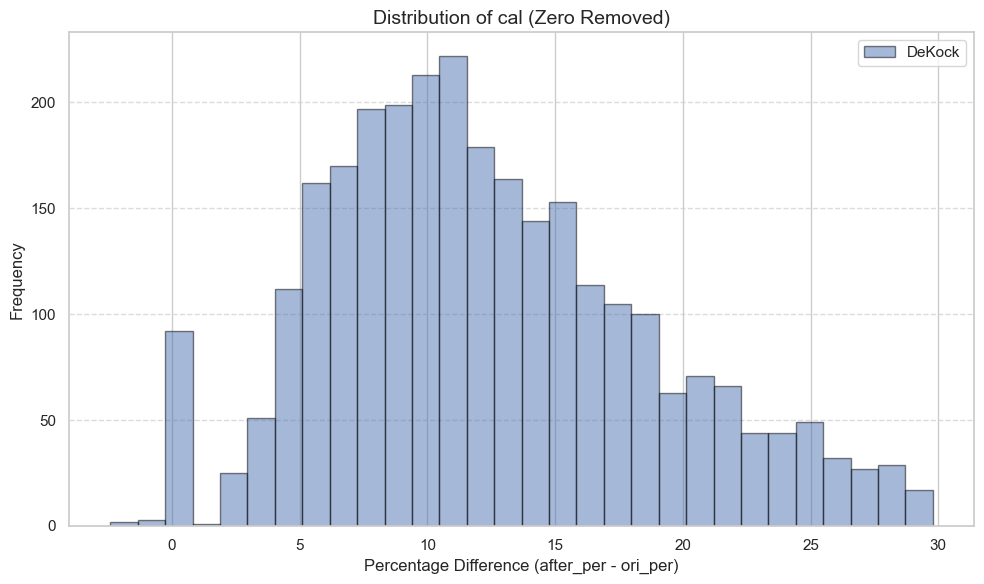

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 读取CSV文件
data = pd.read_csv(r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\em_um_all_info_ana.csv")

# 计算修补前后百分比的差值
data['cal'] = data['after_per'] - data['ori_per']
data['cal'] = data['after_per'] - data['ori_per']

# 去除cal列中零值的数据
filtered_data = data[data['cal'] != 0]

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(filtered_data['cal'].dropna(), bins=30, alpha=0.5, label='DeKock', edgecolor='black')
plt.title('Distribution of cal (Zero Removed)', fontsize=14)
plt.xlabel('Percentage Difference (after_per - ori_per)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()









C:\Users\SEU\AppData\Local\Temp\ipykernel_28164\4220921610.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SEU\AppData\Local\Temp\ipykernel_28164\4220921610.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SEU\AppData\Local\Temp\ipykernel_28164\4220921610.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SEU\AppData\Local\Temp\ipykernel_28164\4220921610.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

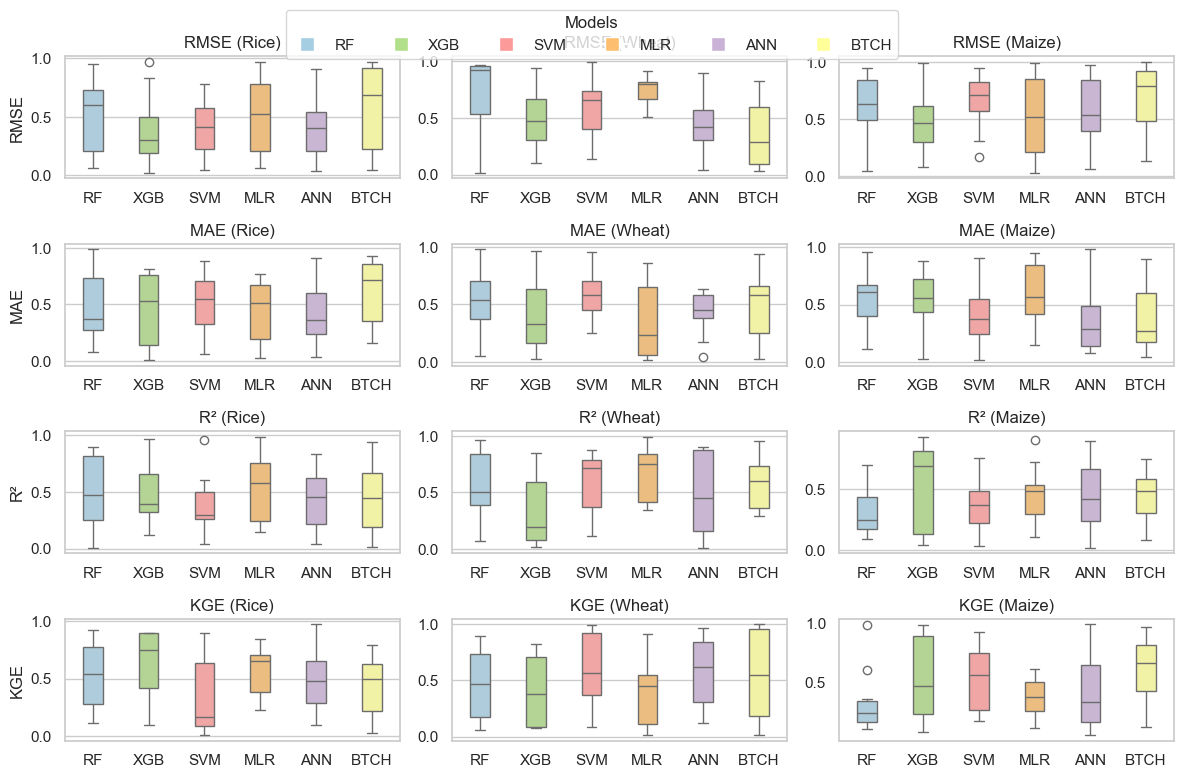

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 生成示例数据
np.random.seed(42)

models = ['RF', 'XGB', 'SVM', 'MLR', 'ANN', 'BTCH']
crops = ['Rice', 'Wheat', 'Maize']
metrics = ['RMSE', 'MAE', 'R²', 'KGE']

data = []
for crop in crops:
    for metric in metrics:
        for model in models:
            values = np.random.rand(10)  # 随机生成10个数据点模拟实验结果
            for value in values:
                data.append([crop, metric, model, value])

df = pd.DataFrame(data, columns=['Crop', 'Metric', 'Model', 'Value'])

# 设置图像尺寸和风格
sns.set(style="whitegrid") 
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# 绘图
light_colors = ['#A6CEE3', '#B2DF8A', '#FB9A99', '#FDBF6F', '#CAB2D6', '#FFFF99']  # light系列配色
for i, metric in enumerate(metrics):
    for j, crop in enumerate(crops):
        ax = axes[i, j]
        sns.boxplot(
            data=df[(df['Crop'] == crop) & (df['Metric'] == metric)],
            x='Model', y='Value', palette=light_colors, ax=ax, width=0.35  # 设置颜色和箱体宽度
        )
        ax.set_title(f"{metric} ({crop})", fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('' if j > 0 else metric)

# 添加图例
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=light_colors[k], markersize=10) for k in range(len(models))]
fig.legend(handles, models, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=6, title='Models')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.grid(False)
plt.show()


按 1level 分类绘制箱线图...
按 2level 分类绘制箱线图...
按 3level 分类绘制箱线图...


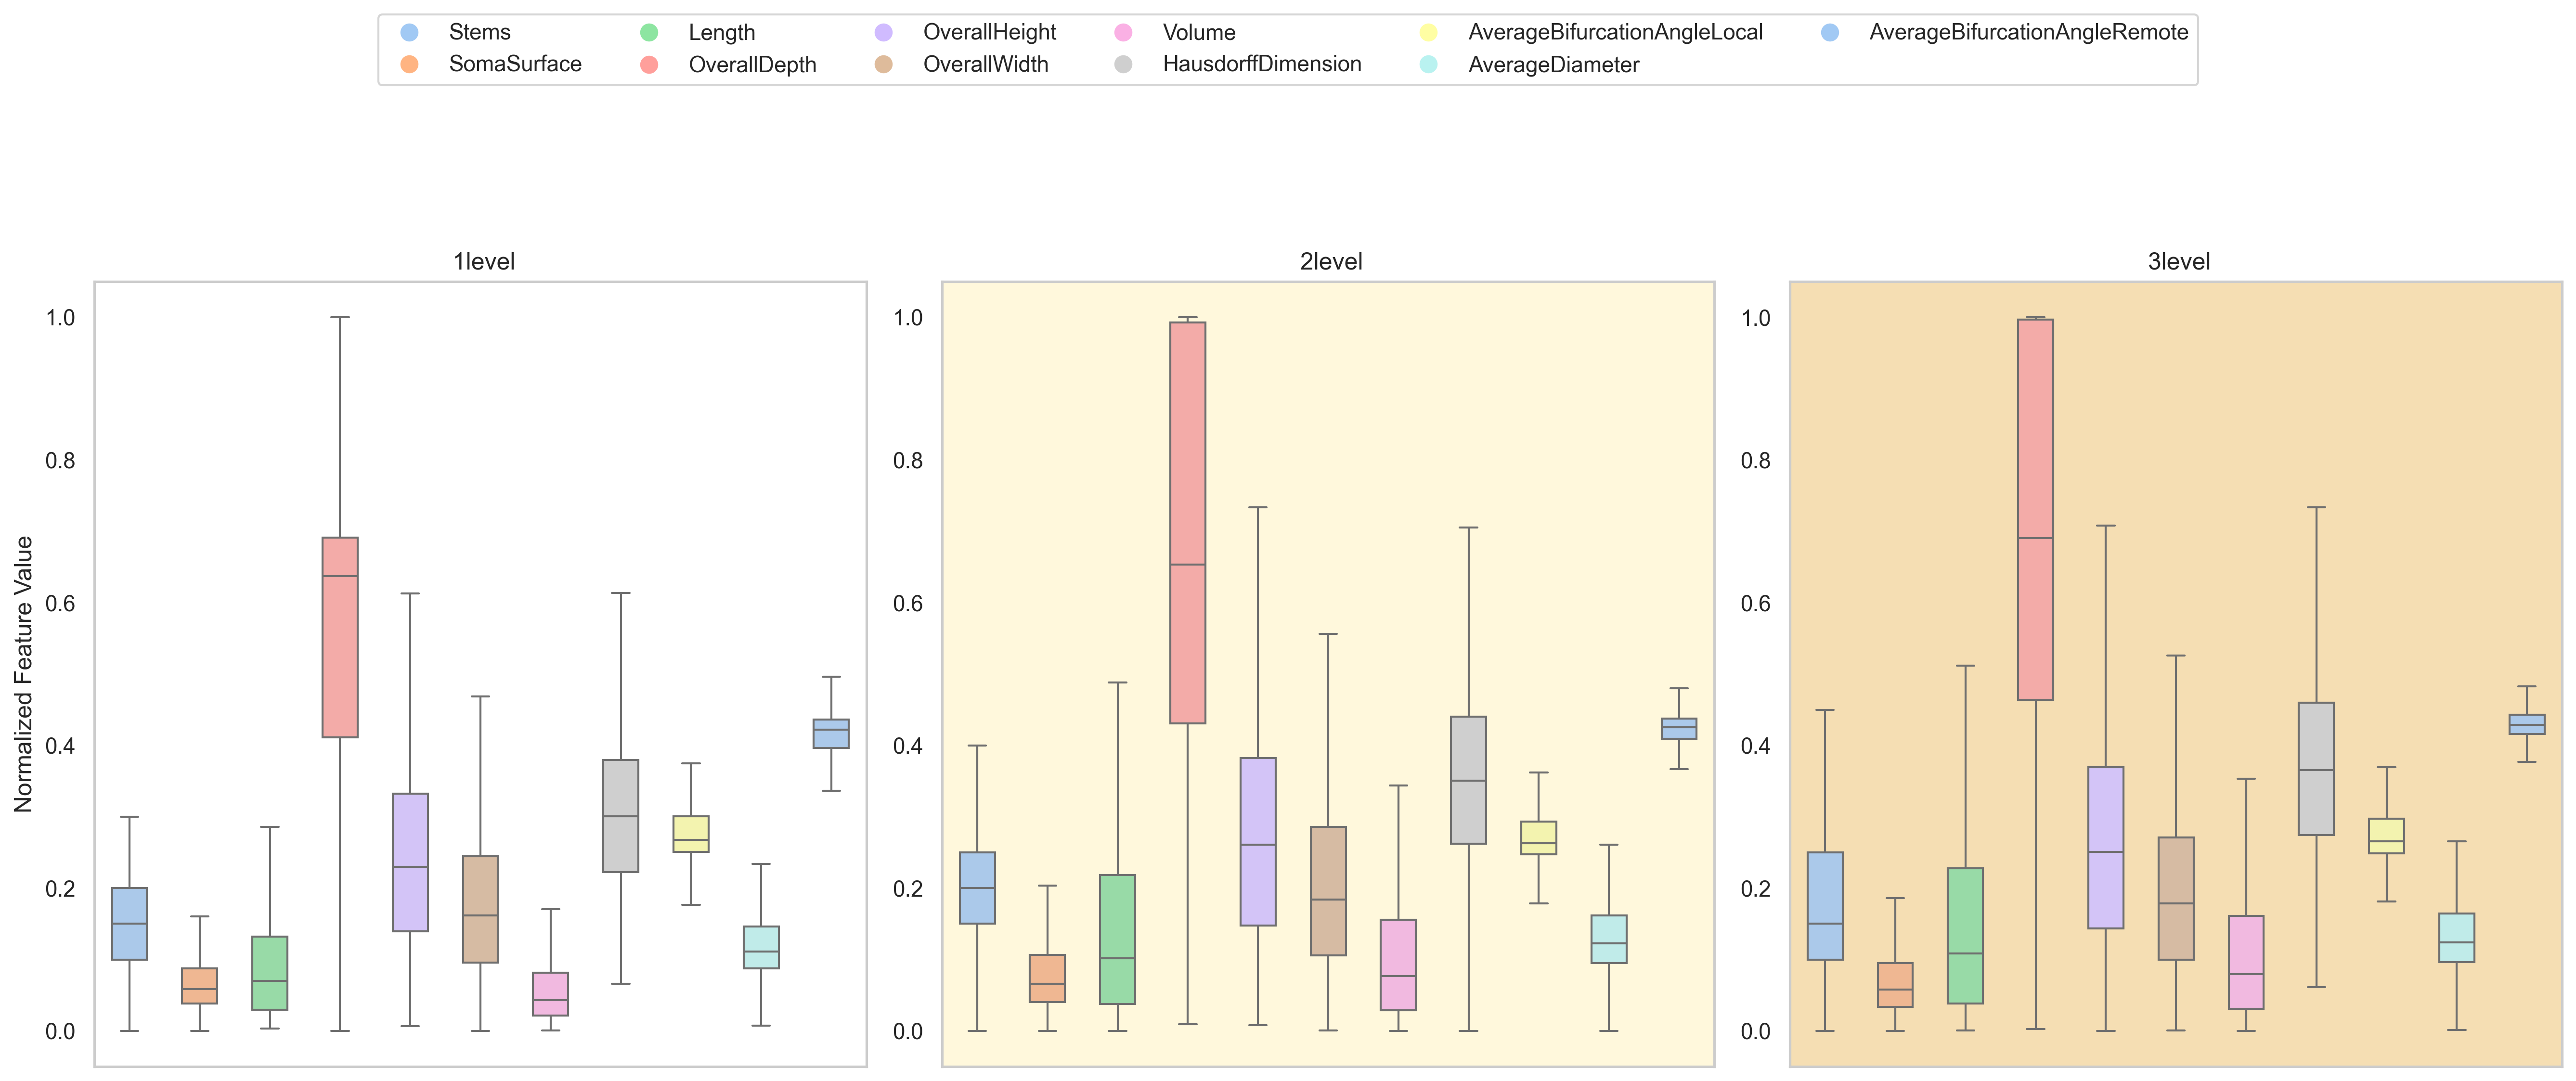

                          Feature   Level      Mean       Std       Min  \
0                           Stems  1level  0.176123  0.077684  0.000000   
1                     SomaSurface  1level  0.068931  0.045089  0.000000   
2                          Length  1level  0.098330  0.092802  0.003063   
3                    OverallDepth  1level  0.606319  0.238586  0.000000   
4                   OverallHeight  1level  0.247752  0.137407  0.006479   
5                    OverallWidth  1level  0.182777  0.117709  0.000000   
6                          Volume  1level  0.062849  0.059931  0.000686   
7              HausdorffDimension  1level  0.306426  0.107557  0.065893   
8    AverageBifurcationAngleLocal  1level  0.283392  0.054474  0.081343   
9                 AverageDiameter  1level  0.121381  0.049055  0.007056   
10  AverageBifurcationAngleRemote  1level  0.412908  0.050009  0.000000   
11                          Stems  2level  0.187897  0.088949  0.000000   
12                    Som

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 加载数据
shared_total_table = pd.read_csv(r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\1radius_all_info.csv")

# 特征列定义
FEATS = [
    'Stems',
    'SomaSurface',
    'Length',
    'OverallDepth',
    'OverallHeight',
    'OverallWidth',
    'Volume',
    'HausdorffDimension',
    'AverageBifurcationAngleLocal',
    'AverageDiameter',
    'AverageBifurcationAngleRemote'
]

# 分类列定义
CATEGORY_COLS = ['level']  # 按level分类

# 检查分类列是否存在
for col in CATEGORY_COLS:
    if col not in shared_total_table.columns:
        raise ValueError(f"数据集中没有 '{col}' 列，请检查数据！")

# 将分类列转换为字符串类型
for col in CATEGORY_COLS:
    shared_total_table[col] = shared_total_table[col].astype(str)

# 数据归一化
scaler = MinMaxScaler()
shared_total_table[FEATS] = scaler.fit_transform(shared_total_table[FEATS])

# 按level分类绘制箱线图
levels = shared_total_table['level'].unique()

# 设置子图
fig, axes = plt.subplots(1, len(levels), figsize=(18, 6),dpi=300)
colors = ['#ffffff', '#fff8dc', '#f5deb3']  # 新的背景色系

for idx, level in enumerate(levels):
    print(f"按 {level} 分类绘制箱线图...")

    subset = shared_total_table[shared_total_table['level'] == level]

    # 绘制子图
    ax = axes[idx]
    sns.boxplot(data=subset[FEATS], ax=ax, palette="pastel", width=0.5, showfliers=False)

    # 设置标题和标签
    ax.set_title(f' {level}')
    ax.set_xticklabels([])  # 移除横轴标签
    ax.set_ylabel('Normalized Feature Value') if idx == 0 else ax.set_ylabel('')
    ax.set_facecolor(colors[idx % len(colors)])  # 设置背景色
    ax.grid(False)

# 添加图例在顶部
palette = sns.color_palette("pastel", len(FEATS))
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i], markersize=10) for i in range(len(FEATS))]
labels = FEATS
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=6)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# 输出统计分析结果
stats_comparison = []
for level in levels:
    subset = shared_total_table[shared_total_table['level'] == level]
    for column in FEATS:
        # 按level计算统计指标
        stats = subset[column].agg(['mean', 'std', 'min', 'max', 'median']).to_dict()
        stats_comparison.append({
            'Feature': column,
            'Level': level,
            'Mean': stats['mean'],
            'Std': stats['std'],
            'Min': stats['min'],
            'Max': stats['max'],
            'Median': stats['median']
        })

# 转换为 DataFrame 并打印
stats_df = pd.DataFrame(stats_comparison)
print(stats_df)


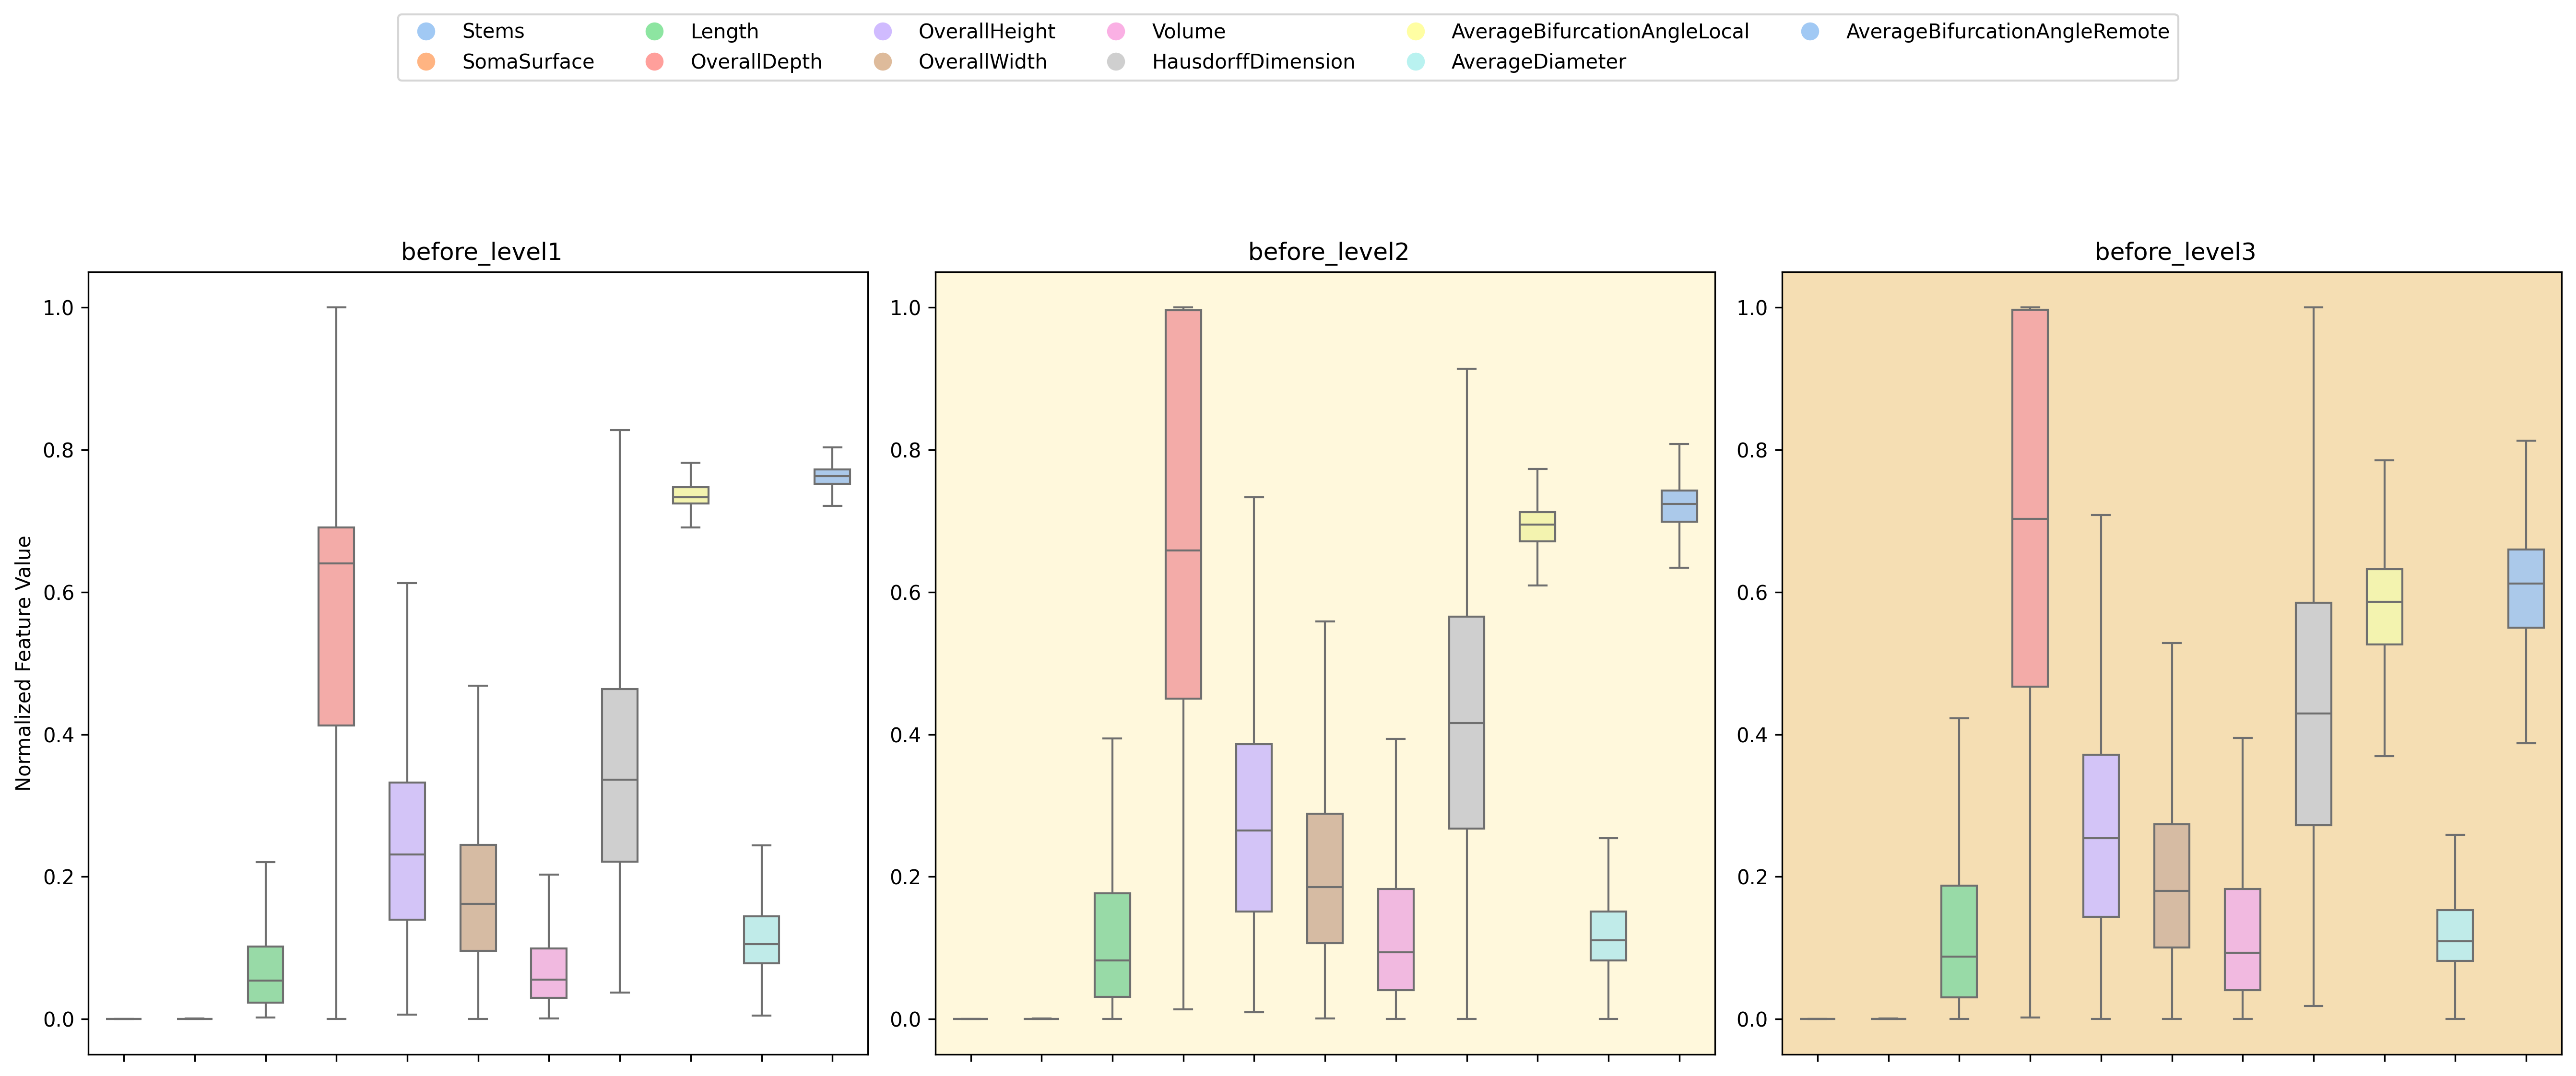

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 基础路径
base_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\comparison"

# 定义表的路径
tables = {
    "before_level1": os.path.join(base_dir, "before_level1.csv"),
    "before_level2": os.path.join(base_dir, "before_level2.csv"),
    "before_level3": os.path.join(base_dir, "before_level3.csv"),
}

# 特征列定义
FEATS = [
    'Stems',
    'SomaSurface',
    'Length',
    'OverallDepth',
    'OverallHeight',
    'OverallWidth',
    'Volume',
    'HausdorffDimension',
    'AverageBifurcationAngleLocal',
    'AverageDiameter',
    'AverageBifurcationAngleRemote'
]

# 读取并合并数据
df_list = []
for level, path in tables.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        temp_df['level'] = level  # 添加level列标识
        df_list.append(temp_df)
    else:
        print(f"警告：文件 {path} 未找到，跳过该level数据！")

# 合并数据
shared_total_table = pd.concat(df_list, ignore_index=True)

# 归一化
scaler = MinMaxScaler()
shared_total_table[FEATS] = scaler.fit_transform(shared_total_table[FEATS])

# 按level分类绘制箱线图
levels = shared_total_table['level'].unique()

# 设置子图
fig, axes = plt.subplots(1, len(levels), figsize=(18, 6), dpi=300)
colors = ['#ffffff', '#fff8dc', '#f5deb3']  # 设定背景色

for idx, level in enumerate(levels):
    subset = shared_total_table[shared_total_table['level'] == level]

    # 绘制子图
    ax = axes[idx]
    sns.boxplot(data=subset[FEATS], ax=ax, palette="pastel", width=0.5, showfliers=False)

    # 设置标题和标签
    ax.set_title(f' {level}')
    ax.set_xticklabels([])  # 移除横轴标签
    ax.set_ylabel('Normalized Feature Value') if idx == 0 else ax.set_ylabel('')
    ax.set_facecolor(colors[idx % len(colors)])  # 设置背景色
    ax.grid(False)

# 添加图例
palette = sns.color_palette("pastel", len(FEATS))
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i], markersize=10) for i in range(len(FEATS))]
labels = FEATS
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=6)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# 计算统计分析
stats_comparison = []
for level in levels:
    subset = shared_total_table[shared_total_table['level'] == level]
    for column in FEATS:
        stats = subset[column].agg(['mean', 'std', 'min', 'max', 'median']).to_dict()
        stats_comparison.append({
            'Feature': column,
            'Level': level,
            'Mean': stats['mean'],
            'Std': stats['std'],
            'Min': stats['min'],
            'Max': stats['max'],
            'Median': stats['median']
        })

# 转换为 DataFrame 并展示
stats_df = pd.DataFrame(stats_comparison)



C:\Users\SEU\AppData\Local\Temp\ipykernel_28164\4069033587.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="pastel")


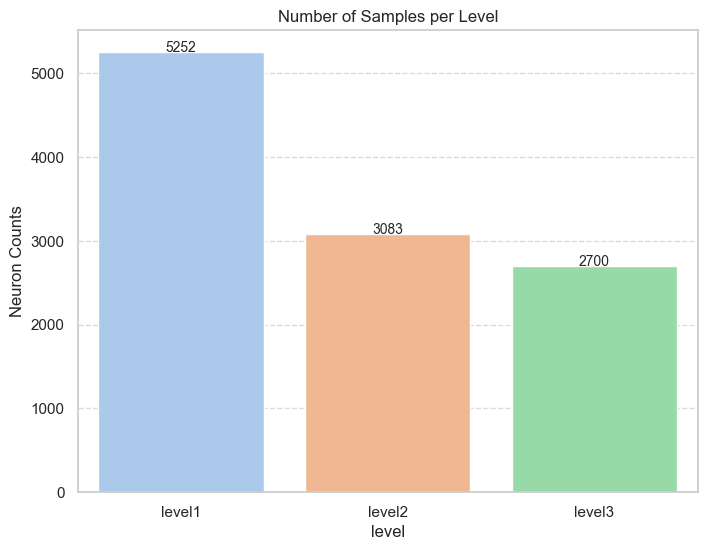

In [54]:
# 代码执行状态被重置，重新加载库并读取数据

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置基础路径
base_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\comparison"

# 获取目录下的所有文件
available_files = set(os.listdir(base_dir))

# 定义文件路径
tables = {
    "level1": os.path.join(base_dir, "before_level1.csv"),
    "level2": os.path.join(base_dir, "before_level2.csv"),
    "level3": os.path.join(base_dir, "before_level3.csv"),
    "level1": os.path.join(base_dir, "after_level1.csv"),
    "level2": os.path.join(base_dir, "after_level2.csv"),
    "level3": os.path.join(base_dir, "after_level3.csv"),
}

# 读取并合并数据
df_list = []
for level, path in tables.items():
    filename = os.path.basename(path)
    if filename in available_files:
        temp_df = pd.read_csv(path)
        temp_df['level'] = level  # 添加level列
        df_list.append(temp_df)
    else:
        print(f"⚠️ 警告：文件 {filename} 未找到，跳过该 level 数据！")

# 检查是否有数据
if not df_list:
    raise ValueError("❌ 错误：未找到任何有效的数据文件，请检查路径和文件名！")

# 合并数据
shared_total_table = pd.concat(df_list, ignore_index=True)

# 统计各 level 的样本数量
level_counts = shared_total_table['level'].value_counts()

# 绘制柱状图
plt.figure(figsize=(8, 6))
sns.barplot(x=level_counts.index, y=level_counts.values, palette="pastel")

# 设置标题和标签
plt.title("Number of Samples per Level")
#plt.xlabel("Level")
plt.ylabel("Neuron Counts")
plt.xticks()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示数值标签
for i, v in enumerate(level_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.show()


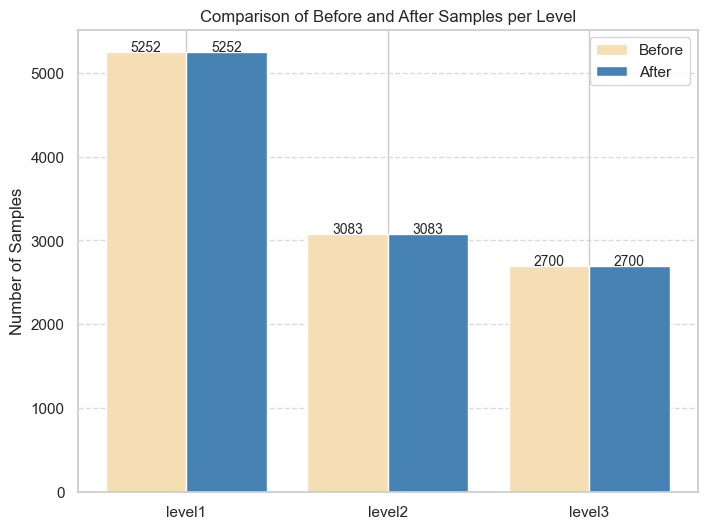

In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置基础路径
base_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\comparison"

# 获取目录下的所有文件
available_files = set(os.listdir(base_dir))

# 定义文件路径
tables = {
    "before_level1": os.path.join(base_dir, "before_level1.csv"),
    "before_level2": os.path.join(base_dir, "before_level2.csv"),
    "before_level3": os.path.join(base_dir, "before_level3.csv"),
    "after_level1": os.path.join(base_dir, "after_level1.csv"),
    "after_level2": os.path.join(base_dir, "after_level2.csv"),
    "after_level3": os.path.join(base_dir, "after_level3.csv"),
}

# 读取数据
level_counts = {}
for label, path in tables.items():
    filename = os.path.basename(path)
    if filename in available_files:
        df = pd.read_csv(path)
        level_counts[label] = len(df)  # 统计每个level的数据量
    else:
        print(f"⚠️ 警告：文件 {filename} 未找到，跳过该数据！")

# 组织数据用于绘图
level_groups = ["level1", "level2", "level3"]
before_counts = [level_counts.get(f"before_{level}", 0) for level in level_groups]
after_counts = [level_counts.get(f"after_{level}", 0) for level in level_groups]

# 绘制分组柱状图
fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.4
x = range(len(level_groups))

bars1 = ax.bar(x, before_counts, width=bar_width, label="Before", color="#f5deb3")
bars2 = ax.bar([i + bar_width for i in x], after_counts, width=bar_width, label="After", color="#4682b4")

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', fontsize=10)

# 设置图例和标签
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(level_groups)
ax.set_ylabel("Number of Samples")
ax.set_title("Comparison of Before and After Samples per Level")
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


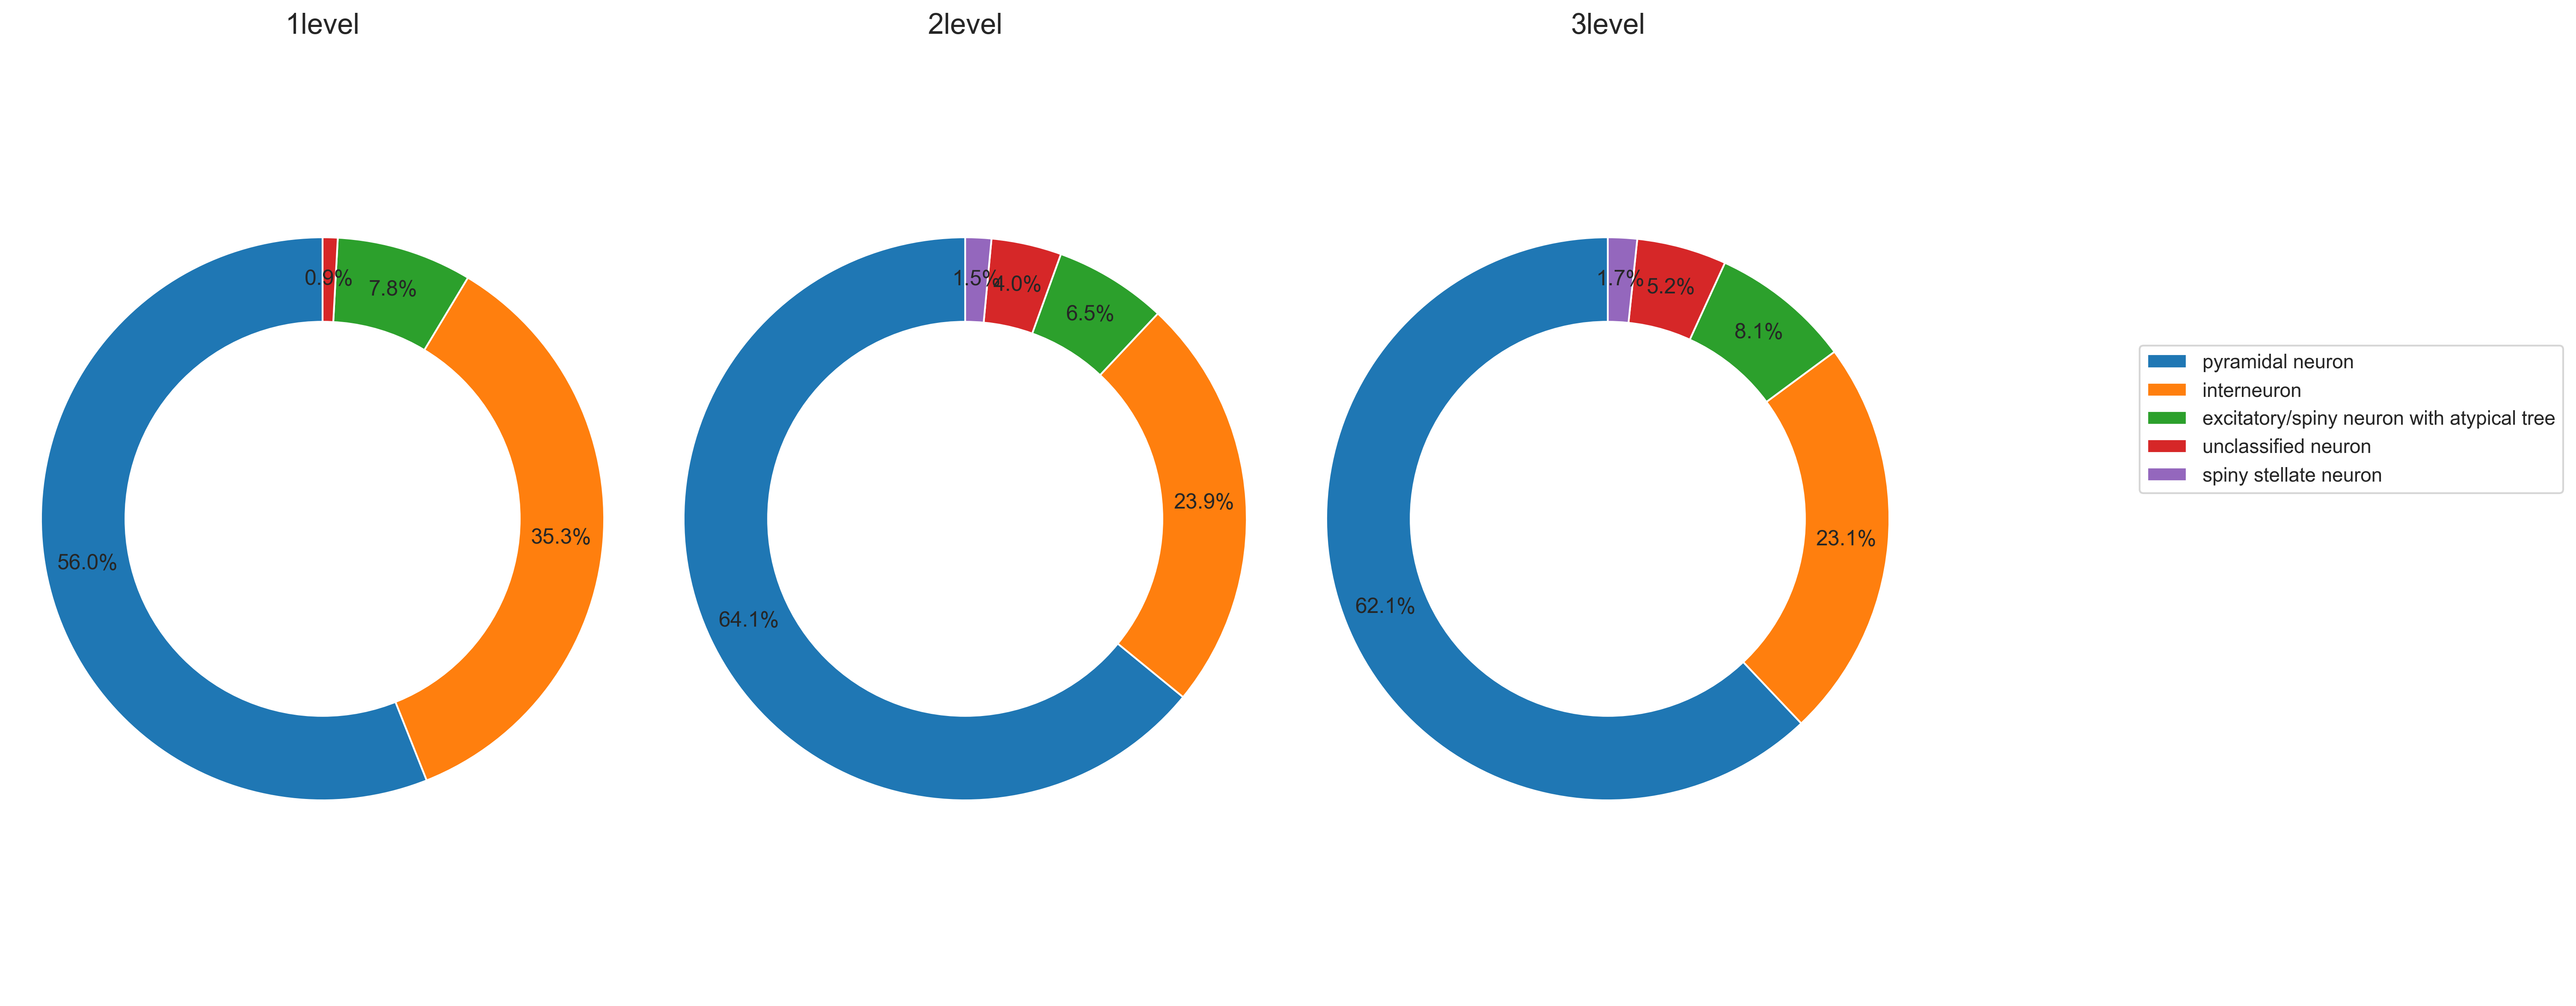

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
shared_total_table = pd.read_csv(r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\data_csv\1radius_all_info.csv")

# 分类列定义
CATEGORY_COLS = ['level', 'Cell type']

# 检查分类列是否存在
for col in CATEGORY_COLS:
    if col not in shared_total_table.columns:
        raise ValueError(f"数据集中没有 '{col}' 列，请检查数据！")

# 将分类列转换为字符串类型（便于分组显示）
for col in CATEGORY_COLS:
    shared_total_table[col] = shared_total_table[col].astype(str)

# 定义色彩方案（使用tab20色系）
colors = sns.color_palette('tab10', n_colors=20)

# 按level分类并绘制环形饼状图
levels = shared_total_table['level'].unique()

# 设置子图布局
fig, axes = plt.subplots(1, len(levels), figsize=(16, 8), dpi=300)

for idx, level in enumerate(levels):
    subset = shared_total_table[shared_total_table['level'] == level]
    counts = subset['Cell type'].value_counts()

    # 绘制环形饼状图
    wedges, texts, autotexts = axes[idx].pie(
        counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=colors[:len(counts)]
    )

    # 绘制圆心空白形成环形效果
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    axes[idx].add_artist(centre_circle)

    axes[idx].set_title(f'{level}',fontsize=16)
    axes[idx].axis('equal')  # 确保饼图为圆形

# 添加图例在右侧
fig.legend(wedges, counts.index, loc='lower center', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
